##  Import libraries and variables

In [18]:
import warnings
warnings.filterwarnings('ignore')
import os
# Use real data for this script. 
os.environ['USE_SYNTHETIC_INPUTS'] = '0'
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from clustering_helpers import get_best_config,train_ovr
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from config import (
    INPUT_DATA_PATH,
    VALIDATION_RESULTS_PATH,
    VARIANCE_OF_MEANS_PATH,
    MEMBERSHIP_PATH,
    ENCODED_MEMBERSHIP_PATH,
    OVR_FEATURE_IMPORTANCE_ALL_PATH,
    OUTPUT_DIR,
    PLOTS_DIR,
    labels_path
)

# Create plots directory
os.makedirs(PLOTS_DIR, exist_ok=True)


## Load Data

In [19]:
best_config = get_best_config(VALIDATION_RESULTS_PATH)
labels_df = pd.read_csv(labels_path(best_config), compression="gzip")
membership = pd.read_csv(MEMBERSHIP_PATH)
df = membership.merge(labels_df, on="patient_id", how="inner")
print(f"Merged {len(df)} patients with cluster labels")
X = pd.read_csv(ENCODED_MEMBERSHIP_PATH)



Merged 50 patients with cluster labels


## Train One vs Rest decision tree 

In [ ]:
combined = train_ovr(X, df["cluster"], OUTPUT_DIR)
combined.to_csv(OVR_FEATURE_IMPORTANCE_ALL_PATH, index=False)
print(f"Saved:") 

In [21]:
display(combined.groupby("cluster", group_keys=False).head(30))

,cluster,feature,gini_importance,mean_in_cluster,mean_outside_cluster,mean_difference,distinguishing_feature
78,0,cat_diabetes_GDM,0.625407,0.500000,0.045455,0.454545,presence
42,0,sex_male,0.184164,0.333333,0.704545,-0.371212,absence
48,0,ethnicity_cat_Unknown,0.146580,0.500000,0.340909,0.159091,presence
4,0,hypertension_preexisting,0.043849,0.500000,0.568182,-0.068182,absence
0,0,diagnosis_community,0.000000,0.000000,0.045455,-0.045455,absence
...,...,...,...,...,...,...,...
189,2,substance_abuse,0.000000,0.000000,0.000000,0.000000,equal
190,2,migrant,0.000000,0.333333,0.382979,-0.049645,absence
191,2,non_english_speaking,0.000000,0.000000,0.042553,-0.042553,absence
193,2,age_band_45-49,0.000000,0.000000,0.127660,-0.127660,absence


## Visualisation of OvR results

Saved


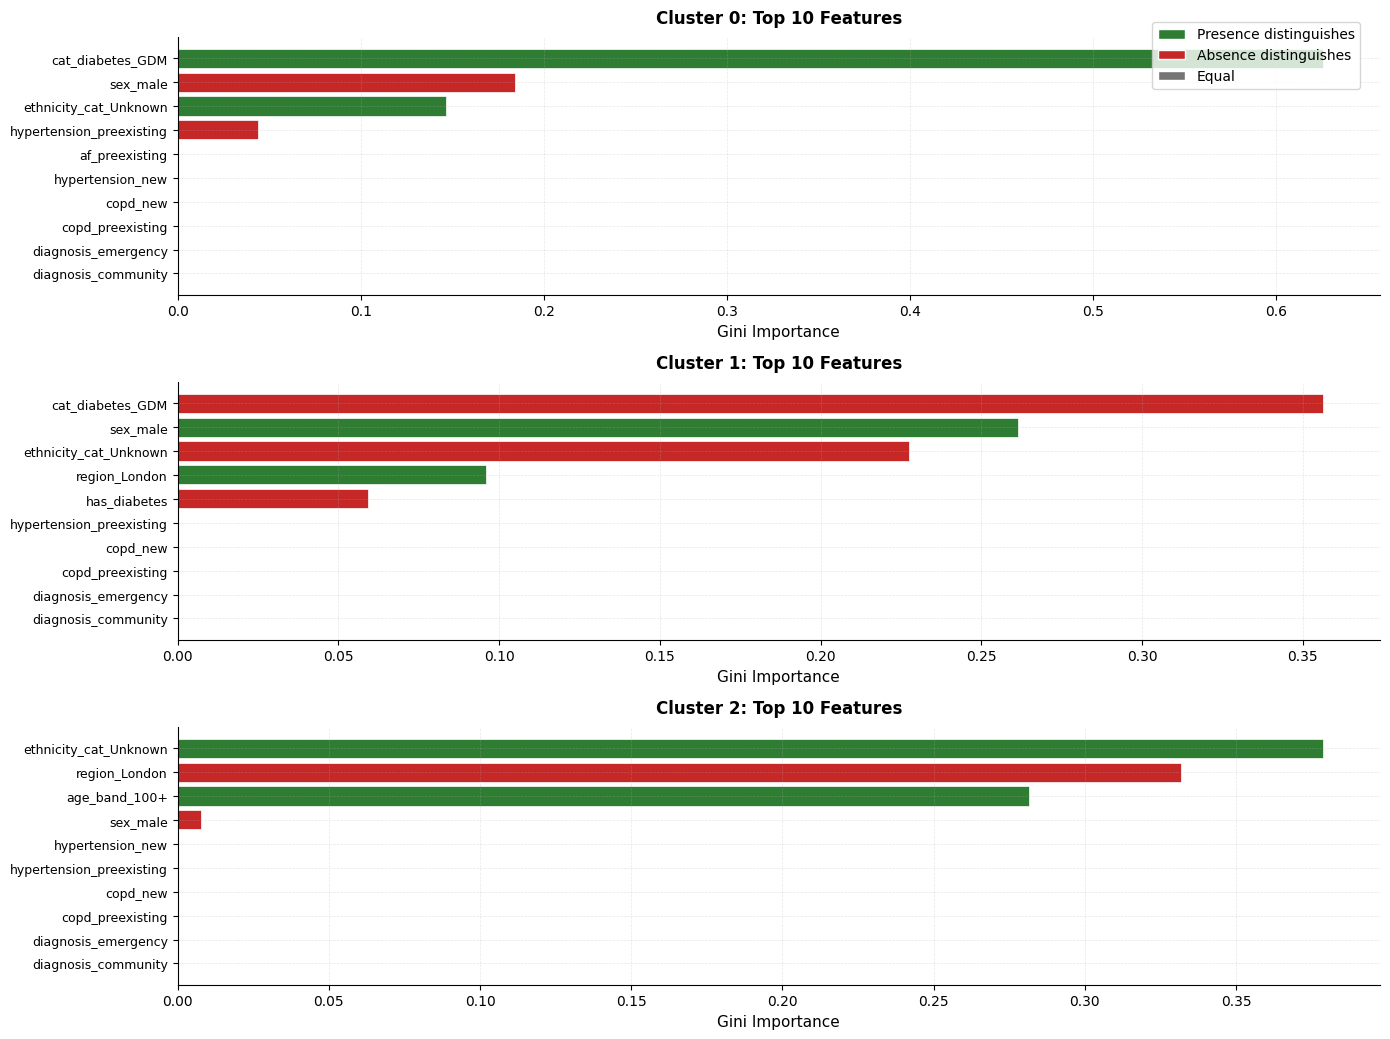

Saved:


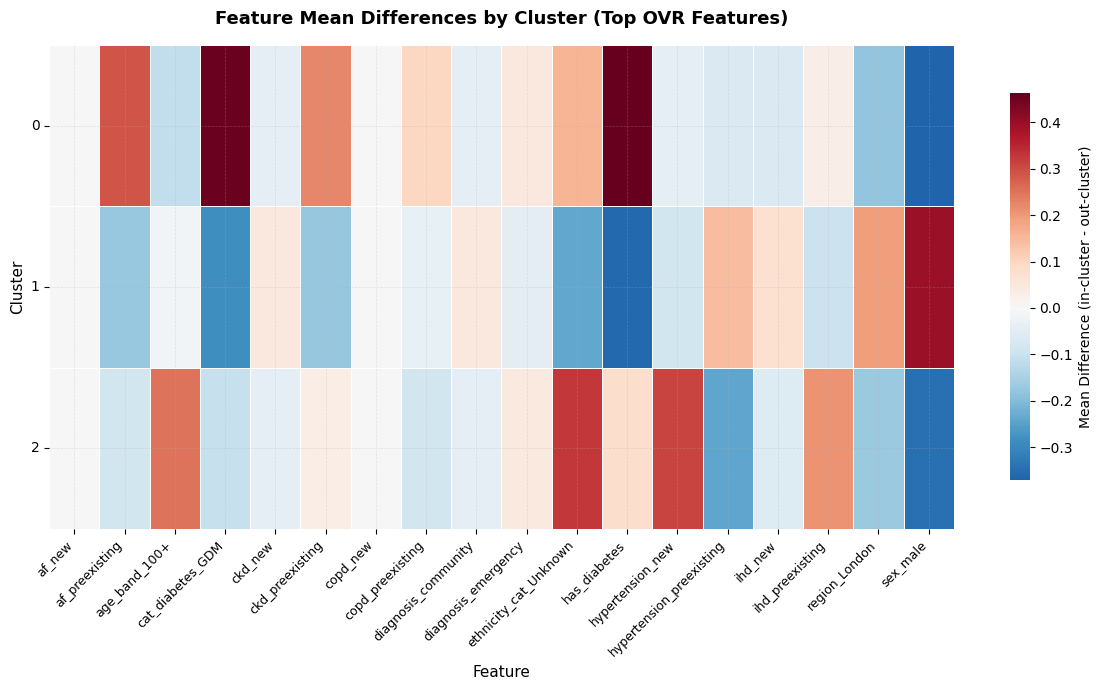

In [22]:
# Plotting setup
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Create plots directory
os.makedirs(PLOTS_DIR, exist_ok=True)

top10 = combined.groupby("cluster", group_keys=False).head(10).copy()

# 1) Top features per cluster (horizontal bar charts)
clusters = sorted(top10["cluster"].unique())
fig, axes = plt.subplots(len(clusters), 1, figsize=(14, max(5, 3.5 * len(clusters))))
if len(clusters) == 1:
    axes = [axes]

# Use a professional color palette
palette = {"presence": "#2E7D32", "absence": "#C62828", "equal": "#757575"}

for ax, c in zip(axes, clusters):
    d = top10[top10["cluster"] == c].sort_values("gini_importance", ascending=True)
    colors = d["distinguishing_feature"].map(palette)
    ax.barh(d["feature"], d["gini_importance"], color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f"Cluster {int(c)}: Top 10 Features", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Gini Importance", fontsize=11)
    ax.tick_params(axis="y", labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Add legend
legend_elements = [
    Patch(facecolor=palette["presence"], label="Presence distinguishes", edgecolor='white'),
    Patch(facecolor=palette["absence"], label="Absence distinguishes", edgecolor='white'),
    Patch(facecolor=palette["equal"], label="Equal", edgecolor='white')
]
fig.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(0.98, 0.98), frameon=True)

plt.tight_layout()
plot1_path = os.path.join(PLOTS_DIR, "ovr_top_features_by_cluster.png")
fig.savefig(plot1_path, dpi=300, bbox_inches='tight', facecolor='white')
print("Saved")
plt.show()

# 2) Heatmap of mean differences for top OVR features
top15 = combined.groupby("cluster", group_keys=False).head(15).copy()
features = (
    top15.groupby("feature")["gini_importance"]
    .max()
    .sort_values(ascending=False)
    .index
)
hm = (
    combined[combined["feature"].isin(features)]
    .pivot(index="cluster", columns="feature", values="mean_difference")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(max(12, 0.5 * hm.shape[1]), max(7, 0.9 * hm.shape[0] + 2)))
sns.heatmap(
    hm,
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"label": "Mean Difference (in-cluster - out-cluster)", "shrink": 0.8},
    ax=ax
)
ax.set_title("Feature Mean Differences by Cluster (Top OVR Features)", 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Feature", fontsize=11)
ax.set_ylabel("Cluster", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

plot2_path = os.path.join(PLOTS_DIR, "ovr_feature_heatmap.png")
fig.savefig(plot2_path, dpi=300, bbox_inches='tight', facecolor='white')
print("Saved:")
plt.show()